# LLM-Powered Automated Equity Research Assistant
**Self Project | Neela Patil**

This notebook builds an automated equity research pipeline that:
1. Fetches real financial data for any stock ticker
2. Scrapes recent news headlines
3. Computes key financial ratios and technical indicators
4. Uses an LLM (Groq/LLaMA3) to generate a structured analyst-style research report



In [1]:
import os
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")   # set it in your environment
 TICKER       = "AAPL"                      # change to any ticker: TSLA, NVDA, RELIANCE.NS etc.
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
# ─── IMPORTS ─────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, textwrap, json
from groq import Groq
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print(f' Libraries loaded. Analysing: {TICKER}')

 Libraries loaded. Analysing: AAPL


## 1. Data Ingestion

In [3]:
# ─── FETCH STOCK DATA ────────────────────────────────────────────────────────
stock  = yf.Ticker(TICKER)
info   = stock.info
hist   = stock.history(period='1y')
news   = stock.news[:8]   # latest 8 headlines

company_name = info.get('longName', TICKER)
sector       = info.get('sector', 'N/A')
industry     = info.get('industry', 'N/A')
country      = info.get('country', 'N/A')

print(f'Company  : {company_name}')
print(f'Sector   : {sector} | Industry: {industry}')
print(f'Country  : {country}')
print(f'Data rows: {len(hist)} trading days fetched')

Company  : Apple Inc.
Sector   : Technology | Industry: Consumer Electronics
Country  : United States
Data rows: 251 trading days fetched


## 2. Financial Ratios & Key Metrics

In [4]:
# ─── KEY FUNDAMENTALS ────────────────────────────────────────────────────────
def safe(key, fmt=None):
    val = info.get(key, None)
    if val is None:
        return 'N/A'
    if fmt == 'pct':
        return f'{val*100:.2f}%'
    if fmt == 'B':
        return f'${val/1e9:.2f}B'
    if fmt == 'x':
        return f'{val:.2f}x'
    return str(round(val, 2))

fundamentals = {
    'Current Price'        : safe('currentPrice'),
    '52W High'             : safe('fiftyTwoWeekHigh'),
    '52W Low'              : safe('fiftyTwoWeekLow'),
    'Market Cap'           : safe('marketCap', 'B'),
    'P/E Ratio (TTM)'      : safe('trailingPE', 'x'),
    'Forward P/E'          : safe('forwardPE', 'x'),
    'P/B Ratio'            : safe('priceToBook', 'x'),
    'EV/EBITDA'            : safe('enterpriseToEbitda', 'x'),
    'Revenue (TTM)'        : safe('totalRevenue', 'B'),
    'Gross Margin'         : safe('grossMargins', 'pct'),
    'Operating Margin'     : safe('operatingMargins', 'pct'),
    'Net Profit Margin'    : safe('profitMargins', 'pct'),
    'ROE'                  : safe('returnOnEquity', 'pct'),
    'ROA'                  : safe('returnOnAssets', 'pct'),
    'Debt/Equity'          : safe('debtToEquity'),
    'Current Ratio'        : safe('currentRatio'),
    'Dividend Yield'       : safe('dividendYield', 'pct'),
    'Beta'                 : safe('beta'),
    'Analyst Target Price' : safe('targetMeanPrice'),
    'Recommendation'       : info.get('recommendationKey', 'N/A').upper(),
}

df_fund = pd.DataFrame(fundamentals.items(), columns=['Metric', 'Value'])
display(df_fund.style.set_caption(f'{company_name} — Key Fundamentals').hide(axis='index'))

Metric,Value
Current Price,313.33
52W High,344.57
52W Low,219.25
Market Cap,$4572.79B
P/E Ratio (TTM),35.93x
Forward P/E,32.94x
P/B Ratio,42.57x
EV/EBITDA,27.28x
Revenue (TTM),$466.82B
Gross Margin,48.65%


## 3. Technical Indicators

In [5]:
# ─── TECHNICAL INDICATORS ────────────────────────────────────────────────────
df = hist.copy()

# Moving averages
df['MA_20']  = df['Close'].rolling(20).mean()
df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

# RSI (14-day)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
df['BB_mid']   = df['Close'].rolling(20).mean()
df['BB_upper'] = df['BB_mid'] + 2 * df['Close'].rolling(20).std()
df['BB_lower'] = df['BB_mid'] - 2 * df['Close'].rolling(20).std()

# MACD
ema12        = df['Close'].ewm(span=12).mean()
ema26        = df['Close'].ewm(span=26).mean()
df['MACD']   = ema12 - ema26
df['Signal'] = df['MACD'].ewm(span=9).mean()

# Volatility (annualised)
df['Daily_Return'] = df['Close'].pct_change()
annual_vol = df['Daily_Return'].std() * np.sqrt(252)

latest = df.iloc[-1]
print(f"RSI (14d)          : {latest['RSI']:.1f}  {' Overbought' if latest['RSI']>70 else ' Oversold' if latest['RSI']<30 else ' Neutral'}")
print(f"Price vs MA50      : {'Above ' if latest['Close'] > latest['MA_50'] else 'Below '}")
print(f"Price vs MA200     : {'Above ' if latest['Close'] > latest['MA_200'] else 'Below '}")
print(f"MACD Signal        : {'Bullish ' if latest['MACD'] > latest['Signal'] else 'Bearish '}")
print(f"Annualised Vol     : {annual_vol*100:.1f}%")
print(f"1Y Return          : {((df['Close'].iloc[-1]/df['Close'].iloc[0])-1)*100:.1f}%")

RSI (14d)          : 40.8   Neutral
Price vs MA50      : Above 
Price vs MA200     : Above 
MACD Signal        : Bearish 
Annualised Vol     : 25.0%
1Y Return          : 37.2%


## 4. Visualisations

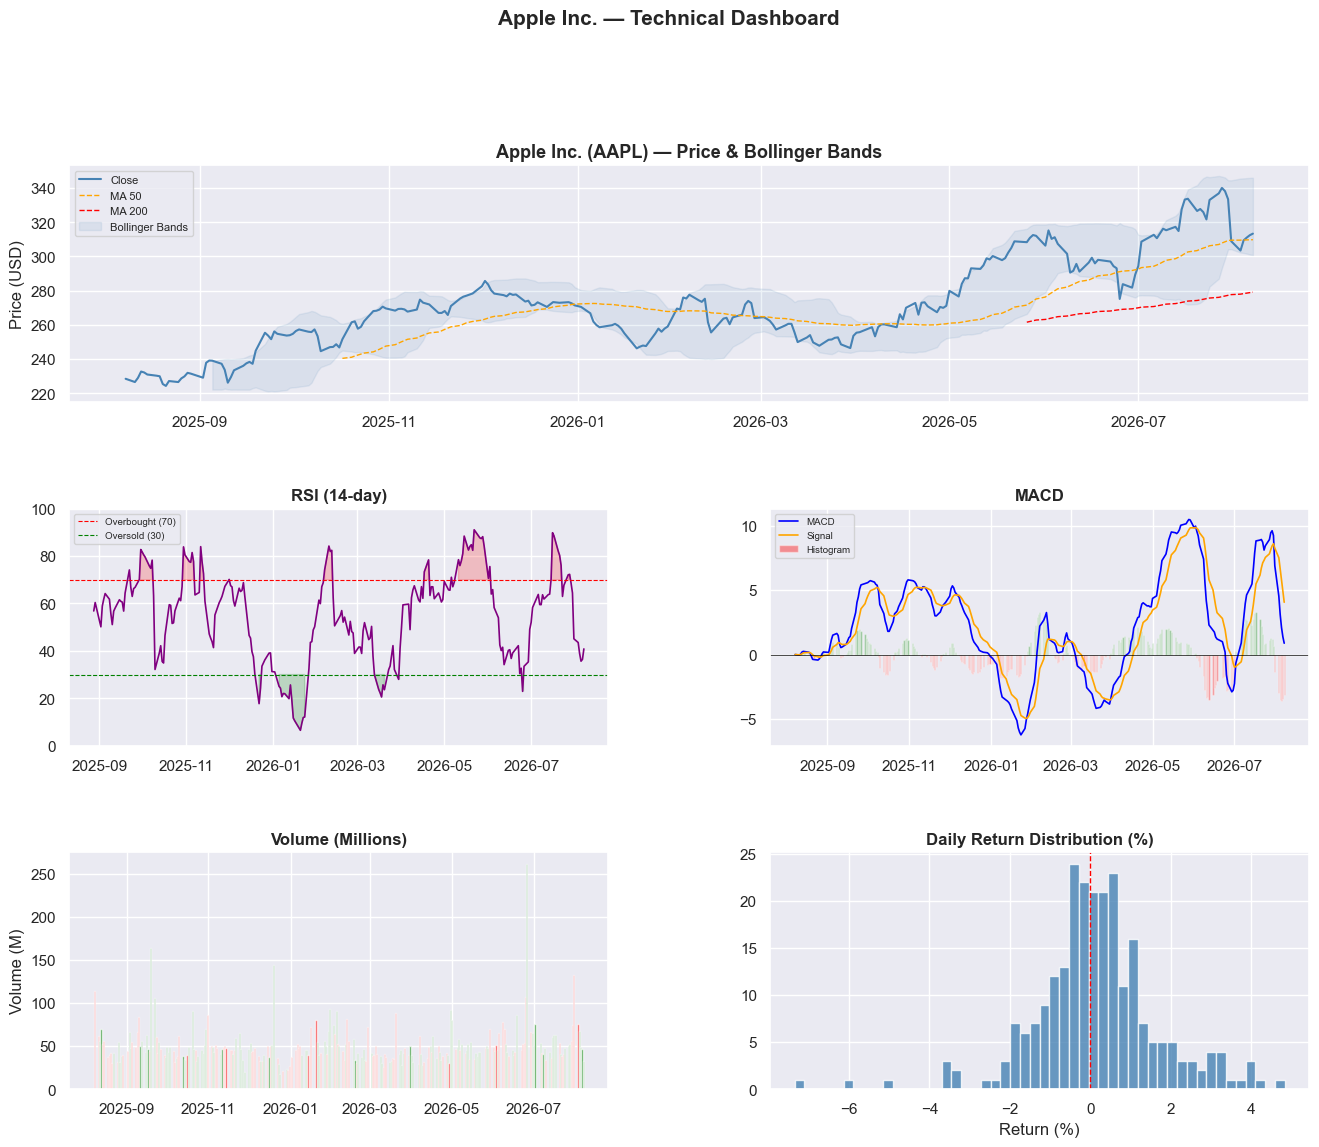

 Dashboard saved.


In [6]:
# ─── DASHBOARD PLOT ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1. Price + Bollinger Bands
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Close'],    color='steelblue', lw=1.5, label='Close')
ax1.plot(df.index, df['MA_50'],    color='orange',    lw=1,   label='MA 50',  linestyle='--')
ax1.plot(df.index, df['MA_200'],   color='red',       lw=1,   label='MA 200', linestyle='--')
ax1.fill_between(df.index, df['BB_upper'], df['BB_lower'], alpha=0.1, color='steelblue', label='Bollinger Bands')
ax1.set_title(f'{company_name} ({TICKER}) — Price & Bollinger Bands', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylabel('Price (USD)')

# 2. RSI
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df.index, df['RSI'], color='purple', lw=1.2)
ax2.axhline(70, color='red',   linestyle='--', lw=0.8, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', lw=0.8, label='Oversold (30)')
ax2.fill_between(df.index, df['RSI'], 70, where=(df['RSI']>=70), alpha=0.2, color='red')
ax2.fill_between(df.index, df['RSI'], 30, where=(df['RSI']<=30), alpha=0.2, color='green')
ax2.set_title('RSI (14-day)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7)

# 3. MACD
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df.index, df['MACD'],   color='blue',   lw=1.2, label='MACD')
ax3.plot(df.index, df['Signal'], color='orange', lw=1.2, label='Signal')
ax3.bar(df.index, df['MACD'] - df['Signal'],
        color=np.where(df['MACD']>df['Signal'], 'green', 'red'), alpha=0.4, label='Histogram')
ax3.axhline(0, color='black', lw=0.5)
ax3.set_title('MACD', fontweight='bold')
ax3.legend(fontsize=7)

# 4. Volume
ax4 = fig.add_subplot(gs[2, 0])
colors = ['green' if r >= 0 else 'red' for r in df['Daily_Return']]
ax4.bar(df.index, df['Volume']/1e6, color=colors, alpha=0.7)
ax4.set_title('Volume (Millions)', fontweight='bold')
ax4.set_ylabel('Volume (M)')

# 5. Return Distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df['Daily_Return'].dropna()*100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax5.axvline(0, color='red', lw=1, linestyle='--')
ax5.set_title('Daily Return Distribution (%)', fontweight='bold')
ax5.set_xlabel('Return (%)')

plt.suptitle(f'{company_name} — Technical Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('technical_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved.')

## 5. News Headlines

In [7]:
# ─── RECENT NEWS ─────────────────────────────────────────────────────────────
print(f' Latest News — {company_name}\n' + '─'*60)
headlines = []
for i, article in enumerate(news, 1):
    title = article.get('content', {}).get('title', article.get('title', 'N/A'))
    headlines.append(title)
    print(f'{i}. {title}')

 Latest News — Apple Inc.
────────────────────────────────────────────────────────────
1. What we know about OpenAI's upcoming handheld device: Bloomberg
2. Canaccord Genuity Shareholders Back Board as Revenue Tops CAD 2 Billion
3. ‘Your refund: $0’: Companies claim billions in tariff refunds, months after Trump floated $2,000 checks
4. Greg Abel concentrates 63% of Berkshire's $355B portfolio in 5 stocks
5. Prediction: Can Apple Stock Reach $400 This Year?
6. Apple (AAPL) Seeks Injunction In AI Trade Secret Lawsuit
7. Meet the Low-Cost Vanguard ETF That Just Gained 11% Over 4 Days, Thanks to a Combined 33% Weighting in Nvidia, Microsoft, Micron, and Broadcom. Here's Why It's Still a Top Buy Now.
8. Microsoft Stock's Peak Margin And Its Azure Bill Are The Same Story


## 6. LLM-Generated Analyst Report

In [8]:
# ─── BUILD CONTEXT FOR LLM ───────────────────────────────────────────────────
tech_summary = f"""
RSI: {latest['RSI']:.1f} | MACD: {'Bullish' if latest['MACD'] > latest['Signal'] else 'Bearish'}
Price vs MA50: {'Above' if latest['Close'] > latest['MA_50'] else 'Below'}
Price vs MA200: {'Above' if latest['Close'] > latest['MA_200'] else 'Below'}
Annualised Volatility: {annual_vol*100:.1f}%
1Y Return: {((df['Close'].iloc[-1]/df['Close'].iloc[0])-1)*100:.1f}%
"""

fund_summary = "\n".join([f"{k}: {v}" for k, v in fundamentals.items()])
news_summary = "\n".join([f"- {h}" for h in headlines])

prompt = f"""
You are a senior equity research analyst at a top investment bank.
Write a structured, professional research report for {company_name} ({TICKER}).

Use the following data:

FUNDAMENTALS:
{fund_summary}

TECHNICAL INDICATORS:
{tech_summary}

RECENT NEWS HEADLINES:
{news_summary}

Structure your report with these exact sections:
1. **Executive Summary** (3-4 sentences, include a clear BUY/HOLD/SELL recommendation)
2. **Business Overview** (sector, business model, competitive position)
3. **Fundamental Analysis** (valuation multiples, margins, balance sheet health)
4. **Technical Analysis** (price trend, momentum, support/resistance)
5. **Key Risks** (3-4 specific risks)
6. **Investment Thesis** (bull case, bear case, and 12-month price target rationale)

Be specific, data-driven, and professional. Use the actual numbers provided.
"""

print(' Prompt built. Sending to LLM...')

 Prompt built. Sending to LLM...


In [9]:
# ─── CALL GROQ LLM ───────────────────────────────────────────────────────────
client = Groq(api_key=GROQ_API_KEY)

response = client.chat.completions.create(
    model="openai/gpt-oss-120b" 
    messages=[
        {"role": "system", "content": "You are a senior equity research analyst. Write detailed, data-driven reports."},
        {"role": "user",   "content": prompt}
    ],
    temperature=0.3,
    max_completion_tokens=4000,
    reasoning_effort="low"
)

report = response.choices[0].message.content

display(Markdown(f"#  Equity Research Report — {company_name} ({TICKER})"))
display(Markdown(report))

#  Equity Research Report — Apple Inc. (AAPL)

**1. Executive Summary**
We initiate coverage on Apple Inc. (AAPL) with a BUY recommendation, driven by the company's strong brand loyalty, diverse product ecosystem, and solid financial performance. With a current price of $313.33, we believe the stock has upside potential to reach our 12-month target price of $322.82. Our analysis is supported by Apple's impressive revenue growth, high margins, and robust return on equity. We expect the company to continue delivering solid results, driven by its innovative products and services.

**2. Business Overview**
Apple Inc. operates in the technology sector, specifically in the consumer electronics and software industries. The company's business model is centered around designing, manufacturing, and marketing a range of products, including iPhones, Macs, iPads, Apple Watches, and AirPods, as well as providing related services such as Apple Music, Apple TV+, and iCloud. Apple's competitive position is strong, with a loyal customer base and a significant market share in the global smartphone and personal computer markets.

**3. Fundamental Analysis**
Our fundamental analysis reveals that Apple's valuation multiples are relatively high, with a P/E ratio (TTM) of 35.93x and a forward P/E of 32.94x. However, the company's strong financial performance justifies these multiples, with a gross margin of 48.65%, an operating margin of 32.62%, and a net profit margin of 27.62%. Apple's return on equity (ROE) is impressive at 148.75%, and its return on assets (ROA) is 27.08%. The company's balance sheet is healthy, with a debt-to-equity ratio of 78.44 and a current ratio of 1.0. The dividend yield is 35.00%, which is attractive for income-seeking investors.

**4. Technical Analysis**
From a technical perspective, Apple's stock price is currently above its 50-day and 200-day moving averages, indicating a positive trend. However, the Relative Strength Index (RSI) is at 40.8, which is neutral, and the Moving Average Convergence Divergence (MACD) is bearish. The annualized volatility is 25.0%, which is relatively high, and the 1-year return is 37.2%, which is strong. While the technical indicators are mixed, we believe the stock's fundamentals will drive its performance over the long term.

**5. Key Risks**
We identify the following key risks for Apple Inc.: (1) intense competition in the smartphone and personal computer markets, which could lead to market share losses and pricing pressure; (2) regulatory risks, particularly in the areas of antitrust and data privacy; (3) supply chain disruptions, which could impact production and delivery of Apple's products; and (4) the potential for a global economic downturn, which could reduce consumer spending on discretionary products like Apple's.

**6. Investment Thesis**
Our bull case for Apple is driven by the company's strong brand, innovative products, and solid financial performance. We expect Apple to continue delivering solid revenue growth, driven by its ecosystem of products and services. Our bear case is centered around the risks mentioned above, particularly competition and regulatory risks. Our 12-month target price of $322.82 is based on a forward P/E of 32.94x and our expectation of continued solid financial performance. We believe Apple's strong fundamentals, combined with its attractive valuation, make it a compelling investment opportunity, and we recommend a BUY rating.

In [10]:
# ─── SAVE REPORT ─────────────────────────────────────────────────────────────
with open(f'{TICKER}_research_report.md', 'w') as f:
    f.write(f'# Equity Research Report — {company_name} ({TICKER})\n\n')
    f.write(report)

print(f' Report saved as {TICKER}_research_report.md')

 Report saved as AAPL_research_report.md


## 7. Multi-Stock Comparison

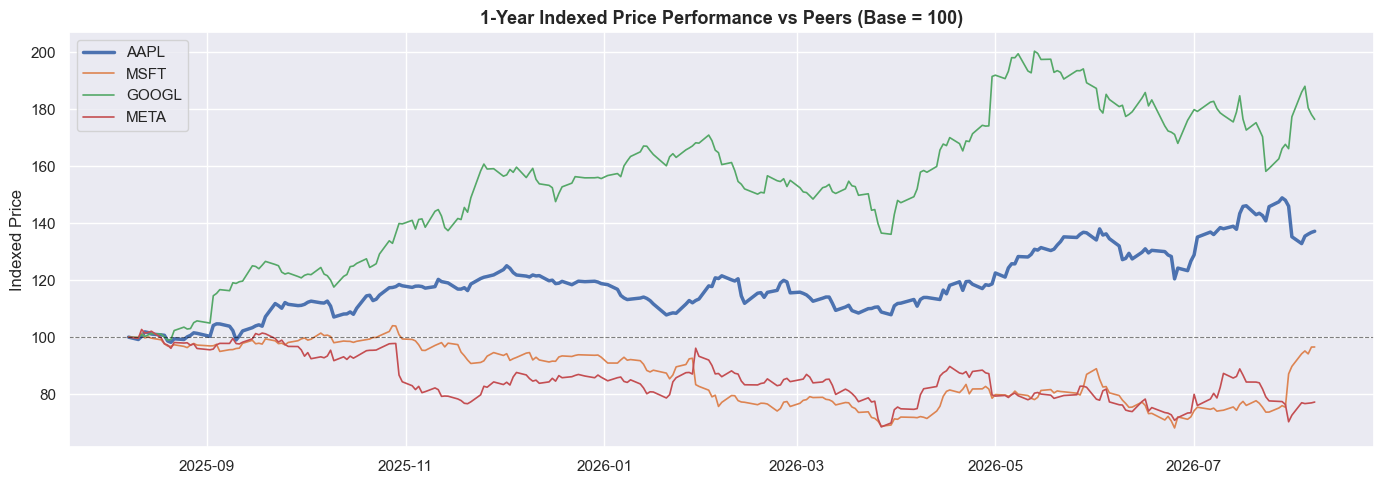

In [11]:
# ─── COMPARE AGAINST PEERS ───────────────────────────────────────────────────
PEERS = [TICKER, 'MSFT', 'GOOGL', 'META']

peer_data = {}
for t in PEERS:
    try:
        h = yf.Ticker(t).history(period='1y')['Close']
        peer_data[t] = (h / h.iloc[0]) * 100   # normalise to 100
    except:
        pass

df_peers = pd.DataFrame(peer_data)

fig, ax = plt.subplots(figsize=(14, 5))
for col in df_peers.columns:
    lw = 2.5 if col == TICKER else 1.2
    ax.plot(df_peers.index, df_peers[col], label=col, lw=lw)

ax.axhline(100, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('1-Year Indexed Price Performance vs Peers (Base = 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.legend()
plt.tight_layout()
plt.savefig('peer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
